CIFAR-10 dataset loaded successfully.
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Using device: cpu

===== TRAINING CNN =====
Epoch 1, Loss: 1.4121
Epoch 2, Loss: 1.0716
Epoch 3, Loss: 0.9282
Epoch 4, Loss: 0.8319
Epoch 5, Loss: 0.7440
Epoch 6, Loss: 0.6727
Epoch 7, Loss: 0.6039
Epoch 8, Loss: 0.5363
Epoch 9, Loss: 0.4786
Epoch 10, Loss: 0.4184


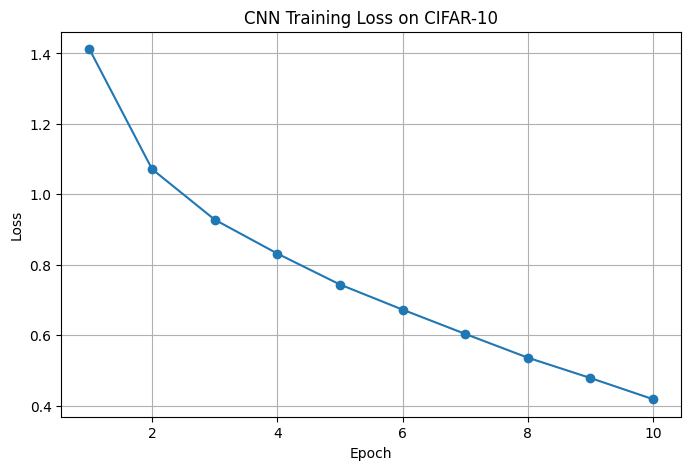


Accuracy on test data: 70.63%

===== LEARNED FILTERS =====


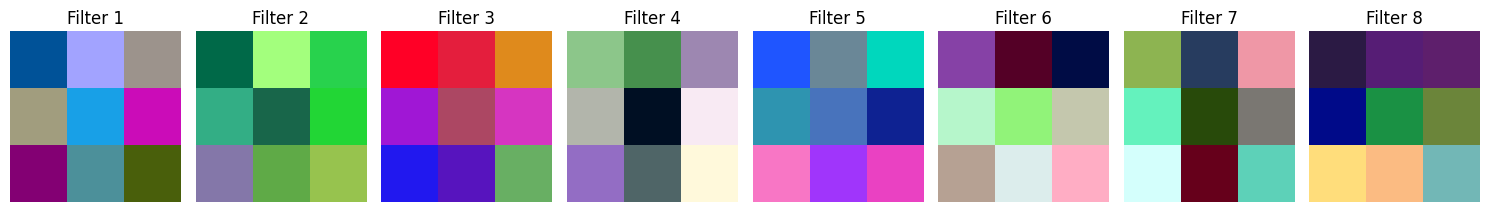

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Load and preprocess CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Training dataset
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

# Testing dataset
testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

# Class names
classes = trainset.classes

print("CIFAR-10 dataset loaded successfully.")
print("Classes:", classes)


# Define CNN architecture
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        # First convolution layer
        self.conv1 = nn.Conv2d(
            3,
            16,
            3,
            padding=1
        )

        # Max pooling
        self.pool = nn.MaxPool2d(
            2,
            2
        )

        # Second convolution layer
        self.conv2 = nn.Conv2d(
            16,
            32,
            3,
            padding=1
        )

        # Fully connected layers
        self.fc1 = nn.Linear(
            32 * 8 * 8,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )

        # ReLU activation
        self.relu = nn.ReLU()

    def forward(self, x):

        # Convolution + ReLU + Pooling
        x = self.pool(
            self.relu(
                self.conv1(x)
            )
        )

        # Convolution + ReLU + Pooling
        x = self.pool(
            self.relu(
                self.conv2(x)
            )
        )

        # Flatten
        x = x.view(
            -1,
            32 * 8 * 8
        )

        # Fully connected layer
        x = self.relu(
            self.fc1(x)
        )

        # Output layer
        x = self.fc2(x)

        return x


# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# Create CNN model
model = SimpleCNN().to(device)

# Loss function
lossfn = nn.CrossEntropyLoss()

# Adam optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# Train the CNN
epochs = 10
training_losses = []

print("\n===== TRAINING CNN =====")

for epoch in range(epochs):

    running_loss = 0.0

    model.train()

    for inputs, labels in trainloader:

        # Move data to device
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(inputs)

        # Calculate loss
        loss = lossfn(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Add loss
        running_loss += loss.item()

    # Calculate average loss
    epoch_loss = running_loss / len(trainloader)

    training_losses.append(epoch_loss)

    print(
        f"Epoch {epoch + 1}, "
        f"Loss: {epoch_loss:.4f}"
    )


# Plot training loss
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    training_losses,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss on CIFAR-10")
plt.grid(True)
plt.show()


# Evaluate model performance
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        # Get predictions
        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

# Calculate accuracy
accuracy = 100 * correct / total

print(
    f"\nAccuracy on test data: "
    f"{accuracy:.2f}%"
)


# Visualize learned filters
def visualize_filters(layer, n_filters=8):

    filters = (
        layer.weight.data
        .clone()
        .cpu()
    )

    fig, axs = plt.subplots(
        1,
        n_filters,
        figsize=(15, 4)
    )

    for i in range(n_filters):

        f = filters[i]

        # Normalize filter for display
        f = (
            f - f.min()
        ) / (
            f.max() - f.min() + 1e-8
        )

        # Convert CHW to HWC
        axs[i].imshow(
            f.permute(1, 2, 0)
        )

        axs[i].axis('off')

        axs[i].set_title(
            f'Filter {i + 1}'
        )

    plt.tight_layout()
    plt.show()


# Display first 8 learned filters
print("\n===== LEARNED FILTERS =====")

visualize_filters(
    model.conv1,
    n_filters=8
)